## Multi-funnel accretion test
Generating a custom dmdpsi profile to allow modelling of the funnelling of matter onto regions other than the pole of the neutron star.

To begin, we add to the existing PM04 profile, given by
\begin{equation}
\frac{dM}{d\psi} = \frac{1}{2}\frac{M_a}{\psi_a}\frac{e^{-\psi/\psi_a}}{1 - e^{-\psi_*/psi_a}}
\end{equation}

a second mass-flux profile, using the PRHL function:
\begin{equation}
f(x,\alpha,\mu,\lambda) = \frac{\alpha \lambda e^{-\lambda(x-\mu)}}{(1 + e^{-\lambda(x-\mu)})^{\alpha+1}}
\end{equation}

0.9999877102900023


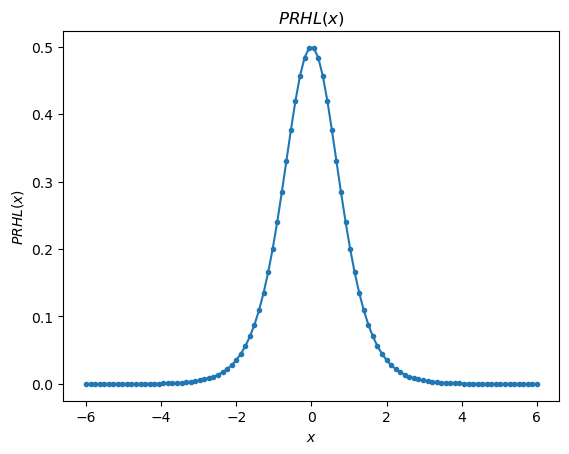

In [11]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson


# Try proportional reversed hazard logistic (PRHL) function  (https://home.iitk.ac.in/~kundu/paper152.pdf)
def prhl(x, alpha, mu, lmda):
    return alpha*lmda*np.exp(-lmda*(x-mu))/(1 + np.exp(-lmda*(x-mu)))**(alpha+1)


# derivative:
def d_prhl(x, alpha, mu, ll):
    return -alpha*ll**2*(np.exp(ll*(x - mu)) - alpha)/(1 + np.exp(-ll*(x-mu)))**alpha/(1 + np.exp(ll*(x - mu)))**2


x = np.linspace(-6, 6, 100)
alpha = 1
mu = 0
ll = 2
prhl_test = prhl(x, alpha, mu, ll)
test_d_prhl = d_prhl(x, alpha, mu, ll)
area = simpson(prhl_test,x)
print(area)

fig, ax = plt.subplots()
ax.plot(x, prhl_test, '.-')
ax.set(title=r'$PRHL(x)$', xlabel='$x$', ylabel=r'$PRHL(x)$')
plt.show()

96.6174038199707 0.9993232485107668 96.6174038199707


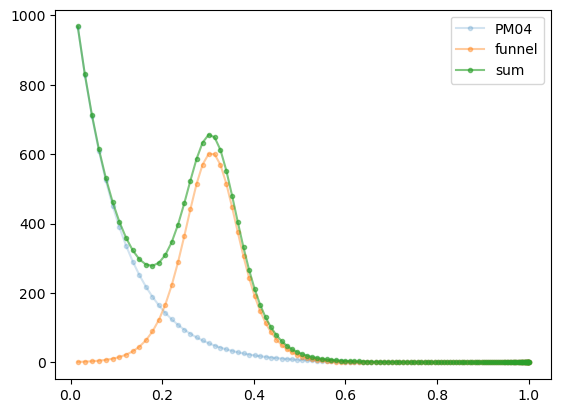

In [30]:
# now try it scaled to typical parameters
B_star = 1e8
R_star = 1e4
cs = 1e6
G = 6.67e-11
M_sol = 1.989e30
M_star = 1.4*M_sol
psi_star = B_star*R_star**2/2
m_accretion = 1e-7
ma = m_accretion * M_sol
x0 = cs*cs*R_star*R_star/(G*M_star)
F0 = cs * cs * ma/x0/x0/x0
psi_0 = np.sqrt(F0)
n_contours = 127
dmu = 1/127
bratio = 10

mu_levels = np.empty(n_contours)
for i in range(n_contours):
    contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
    mu_levels[i] = contour_mesh_value*dmu

psi_levels = (psi_star/psi_0)*(1-mu_levels*mu_levels)

x = psi_levels*psi_0/psi_star
mu_45 = np.arccos(np.pi/4)
psi_45 = psi_star/psi_0 * (1 - mu_45**2)**2

dmdpsi_pm04 = 0.5*psi_0/psi_star*bratio*np.exp(-psi_levels*psi_0/psi_star*bratio)/(1. - np.exp(-bratio))
dmdpsi_funnel = prhl(x, 1, psi_45*psi_0/psi_star, 25)

dmdpsi_pm04_area = simpson(dmdpsi_pm04, x)
dmdpsi_funnel_area = simpson(dmdpsi_funnel, x)

dmdpsi_funnel_rescale = dmdpsi_funnel * dmdpsi_pm04_area / dmdpsi_funnel_area
dmdpsi_funnel_rescale_area = simpson(dmdpsi_funnel_rescale,x)

dmdpsi_combined = dmdpsi_pm04 + dmdpsi_funnel_rescale
print(dmdpsi_pm04_area, dmdpsi_funnel_area, dmdpsi_funnel_rescale_area)

fig, ax = plt.subplots()
ax.plot(x, dmdpsi_pm04, '.-', alpha=0.2, label='PM04')
ax.plot(x, dmdpsi_funnel_rescale, '.-', alpha=0.4, label='funnel')
ax.plot(x,dmdpsi_combined, '.-', alpha=0.6, label = 'sum')
ax.legend()
plt.show()